In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score


In [5]:
X, y = fetch_california_housing(return_X_y=True, as_frame=True)

feature_names = X.columns

print("Dataset shape:", X.shape)
print("Number of features:", len(feature_names))


Dataset shape: (20640, 8)
Number of features: 8


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_train_pred_lr = lr.predict(X_train_scaled)
y_test_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression")
print("Train R2:", r2_score(y_train, y_train_pred_lr))
print("Test  R2:", r2_score(y_test, y_test_pred_lr))


Linear Regression
Train R2: 0.6125511913966952
Test  R2: 0.575787706032451


In [9]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_train_pred_ridge = ridge.predict(X_train_scaled)
y_test_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge Regression")
print("Train R2:", r2_score(y_train, y_train_pred_ridge))
print("Test  R2:", r2_score(y_test, y_test_pred_ridge))


Ridge Regression
Train R2: 0.6125511218634558
Test  R2: 0.5758157428913684


The baseline linear regression model achieved a training R² of 0.6125 and a test R² of 0.5757, indicating mild overfitting. After applying Ridge regression with α = 1.0, the training performance remained nearly unchanged, while the test R² increased slightly to 0.5758. This shows that L2 regularization stabilizes the model and marginally improves generalization without sacrificing predictive power.

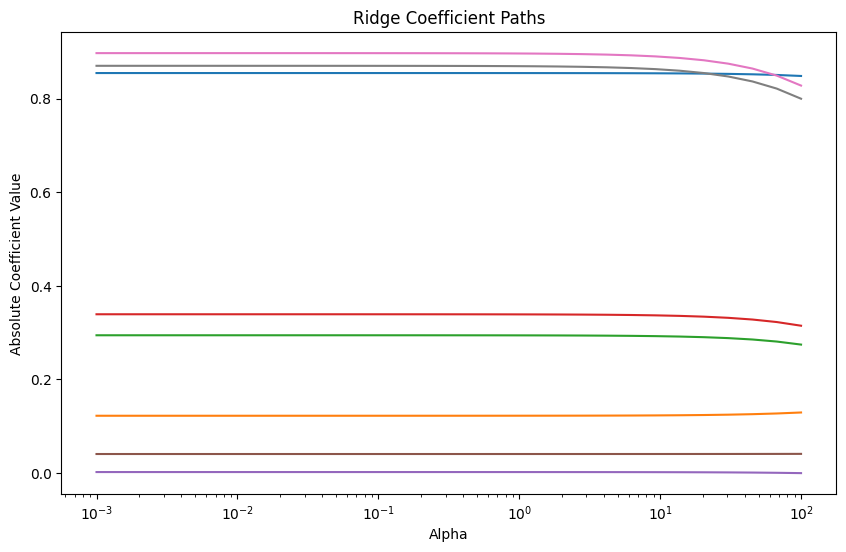

In [10]:
alphas = np.logspace(-3, 2, 30)
ridge_coefs = []

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    ridge_coefs.append(model.coef_)

plt.figure(figsize=(10,6))
for i in range(len(feature_names)):
    plt.plot(alphas, np.abs(np.array(ridge_coefs)[:, i]))

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Absolute Coefficient Value")
plt.title("Ridge Coefficient Paths")
plt.show()


The Ridge coefficient path plot shows that as the regularization parameter α increases, the magnitudes of all coefficients decrease smoothly toward zero. However, none of the coefficients become exactly zero, confirming that Ridge regression performs weight shrinkage rather than feature elimination. This behavior demonstrates how L2 regularization controls model complexity and stabilizes the solution while retaining all features.

In [11]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_train_pred_lasso = lasso.predict(X_train_scaled)
y_test_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso Regression")
print("Train R2:", r2_score(y_train, y_train_pred_lasso))
print("Test  R2:", r2_score(y_test, y_test_pred_lasso))


Lasso Regression
Train R2: 0.4974185516409556
Test  R2: 0.48136113250290735


In [12]:
lasso_results = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso.coef_
})

print(lasso_results)
print("\nNumber of Zero Coefficients:",
      np.sum(lasso_results["Coefficient"] == 0))


      Feature  Coefficient
0      MedInc     0.710598
1    HouseAge     0.106453
2    AveRooms    -0.000000
3   AveBedrms     0.000000
4  Population    -0.000000
5    AveOccup    -0.000000
6    Latitude    -0.011469
7   Longitude    -0.000000

Number of Zero Coefficients: 5


The Lasso regression model achieved a training R² of 0.497 and a test R² of 0.481, which are lower than the baseline and Ridge models, indicating increased bias due to stronger regularization. However, Lasso produced a sparse solution by setting five out of eight feature coefficients to exactly zero. This demonstrates L1 regularization’s ability to perform automatic feature selection, resulting in a simpler and more interpretable model.

In [13]:
enet = ElasticNet(alpha=0.1, l1_ratio=0.5)
enet.fit(X_train_scaled, y_train)

y_train_pred_enet = enet.predict(X_train_scaled)
y_test_pred_enet = enet.predict(X_test_scaled)

print("Elastic Net")
print("Train R2:", r2_score(y_train, y_train_pred_enet))
print("Test  R2:", r2_score(y_test, y_test_pred_enet))


Elastic Net
Train R2: 0.5307617190050338
Test  R2: 0.5147647043408876


In [14]:
compare_df = pd.DataFrame({
    "Feature": feature_names,
    "Lasso Coef": lasso.coef_,
    "ElasticNet Coef": enet.coef_
})

print(compare_df)


      Feature  Lasso Coef  ElasticNet Coef
0      MedInc    0.710598         0.713818
1    HouseAge    0.106453         0.137288
2    AveRooms   -0.000000        -0.000000
3   AveBedrms    0.000000         0.000000
4  Population   -0.000000         0.000000
5    AveOccup   -0.000000        -0.000000
6    Latitude   -0.011469        -0.175737
7   Longitude   -0.000000        -0.133250


The Elastic Net model achieved a training R² of 0.531 and a test R² of 0.515, which lies between Ridge and Lasso performance. Compared to Lasso, Elastic Net retained additional features such as Longitude with non-zero coefficients, indicating reduced aggressiveness in feature elimination. This demonstrates Elastic Net’s grouping effect, where correlated predictors are kept together with moderate shrinkage. Overall, Elastic Net provides a balance between sparsity and stability.

In [15]:
summary = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso", "Elastic Net"],
    "Train R2": [
        r2_score(y_train, y_train_pred_lr),
        r2_score(y_train, y_train_pred_ridge),
        r2_score(y_train, y_train_pred_lasso),
        r2_score(y_train, y_train_pred_enet)
    ],
    "Test R2": [
        r2_score(y_test, y_test_pred_lr),
        r2_score(y_test, y_test_pred_ridge),
        r2_score(y_test, y_test_pred_lasso),
        r2_score(y_test, y_test_pred_enet)
    ]
})

print(summary)


               Model  Train R2   Test R2
0  Linear Regression  0.612551  0.575788
1              Ridge  0.612551  0.575816
2              Lasso  0.497419  0.481361
3        Elastic Net  0.530762  0.514765


Ridge improves stability, Lasso performs feature selection, and Elastic Net balances both, which is clearly reflected in the training and testing R² values.